In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.decomposition import PCA
import pickle

from tqdm.notebook import tqdm

In [10]:
# sampling utils

def random_sequence(n,T):
      partition = random_partition(n)
      partition = np.cumsum(partition)
      if len(partition) > T:
        partition = partition[:T-1] + sum(partition[T-1:])
      tokens = np.random.choice(range(T),size=len(partition),replace=False)
      sequence = np.zeros(n)
      sequence[:partition[0]] = tokens[0]
      for i,j,t in zip(partition[:-1],partition[1:],tokens[1:]):
        sequence[i:j] = t
      np.random.shuffle(sequence)
      return np.array(sequence,dtype=int)

def random_partition(n):
    if n == 0:
        return []
    if n == 1:
        return [1]
    k = np.random.randint(1,n+1)
    return [k] + random_partition(n-k)

In [11]:
model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1",)#torch_dtype=torch.float16)
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")#,torch_dtype=torch.float16)
model.to('cuda')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): MistralRotaryEmbedding()
        )
        (mlp): MistralMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
     

In [12]:
def generate_prompts(item_list_ids, items, category):
    
    """
    Generate prompts for the model to predict the occurence of an item in a list of items between 1 and 12, tranformed to langauge.
    """
    
    compare = "By comparing all ten items in the previous list to one another"
    summarize = f"By summarising the occurrences of {category} in the previous list of ten items"

    positions = ['first', 'second', 'third', 'fourth', 'fifth', 'sixth', 'seventh', 'eighth', 'ninth', 'tenth']
    position_ids = [0,1,2,3,4,5,6,7,8,9]
    item_ids = [0,1,2,3,4,5,6,7,8,9,10,11]


    item_list_func = lambda item_list_ids, items : '[' + ', '.join([f"'{items[i]}'" for i in item_list_ids]) + ']'

    prompts = []
    item_list = item_list_func(item_list_ids, items)
    for item_id in item_ids:
        prompt_1 = f"{item_list}: {summarize}, we find that '{items[item_id]}' appears "#, we find that 'august' appears we find that the fifth item in the list appears " #the month of the year 
        prompt_2 = f"{item_list}: {compare}, we find that '{items[item_id]}' appears " #out of the months of the year, the month of the year 
        prompts.append((prompt_1, item_list_ids, 'summarize', 'Q_month', item_id, len([a for a in item_list_ids if a == item_id])))
        prompts.append((prompt_2, item_list_ids, 'compare' , 'Q_month', item_id, len([a for a in item_list_ids if a == item_id])))
    
    for position_id in position_ids:
        prompt_3 = f"{item_list}: {summarize}, we find that the {positions[position_id]} item of the list appears " #the month of the year 
        prompt_4 = f"{item_list}: {compare}, we find that the {positions[position_id]} item of the list appears "
        prompts.append((prompt_3, item_list_ids, 'summarize', 'Q_pos', position_id, len([a for a in item_list_ids if a == item_list_ids[position_id]])))
        prompts.append((prompt_4, item_list_ids, 'compare', 'Q_pos', position_id, len([a for a in item_list_ids if a == item_list_ids[position_id]])))

    return prompts

def predict_occurence(prompt):
    model_inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    generation_output = model.generate(**model_inputs, pad_token_id=tokenizer.eos_token_id, max_new_tokens=10, do_sample=False,return_dict_in_generate=True,)
    generated_ids = generation_output.sequences 
    output = tokenizer.batch_decode(generated_ids)[0]
    try:
        prediction = int(output.split(prompt)[1].split(' ')[0])
    except:
        prediction = None
    return prediction

In [14]:
model_name = 'mistral_32'

In [15]:
def run_exp(category, items,n_times=100):

    results = []

    filename = f'{model_name}_{category.replace(" ","_")}_results.pkl'

    print("sampling labels")
    for _ in tqdm(range(n_times)):
        item_list_ids = random_sequence(10,12)
        prompts = generate_prompts(item_list_ids, items, category)
        for prompt, _, Q_mode, Q_loc, _, ground_truth in prompts:
            prediction = predict_occurence(prompt)
            results.append((ground_truth, prediction, Q_mode, Q_loc, 'uniform_counts'))
        pickle.dump(results,open(filename,'wb'))
    
    print("sampling inputs") 
    for _ in tqdm(range(n_times)):
        item_list_ids = np.random.randint(0,12,10)
        prompts = generate_prompts(item_list_ids, items, category)
        for prompt, _, Q_mode, Q_loc, _, ground_truth in prompts:
            prediction = predict_occurence(prompt)
            results.append((ground_truth, prediction, Q_mode, Q_loc, 'uniform_inputs'))
        pickle.dump(results,open(filename,'wb'))
    
    pickle.dump(results,open(filename,'wb'))
    print('done.')

In [16]:
experiments = [('months of the year',['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']),
                ('letters of the alphabet',['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']),
                ('animals of the land',['dog', 'cat', 'donkey', 'horse', 'elephant', 'giraffe', 'lion', 'tiger', 'bear', 'wolf', 'zebra', 'monkey'])]

In [ ]:
for category, items in experiments:
    print(category)
    run_exp(category, items,n_times=100) # roughly 30s to sample both inputs and labels for n_times-1 for mistral

months of the year
sampling labels


  0%|          | 0/100 [00:00<?, ?it/s]

sampling inputs


  0%|          | 0/100 [00:00<?, ?it/s]

done.
letters of the alphabet
sampling labels


...

  0%|          | 0/100 [00:00<?, ?it/s]

done.
animals of the land
sampling labels


  0%|          | 0/100 [00:00<?, ?it/s]

sampling inputs


  0%|          | 0/100 [00:00<?, ?it/s]

For months of the year skipped 0.000 fraction of predictions due to out of bounds or None.
For letters of the alphabet skipped 0.007 fraction of predictions due to out of bounds or None.
For animals of the land skipped 0.000 fraction of predictions due to out of bounds or None.


/tmp/ipykernel_1961744/1617334539.py:69: RuntimeWarning: invalid value encountered in divide
  R = R / R.sum(axis=0,keepdims=True)


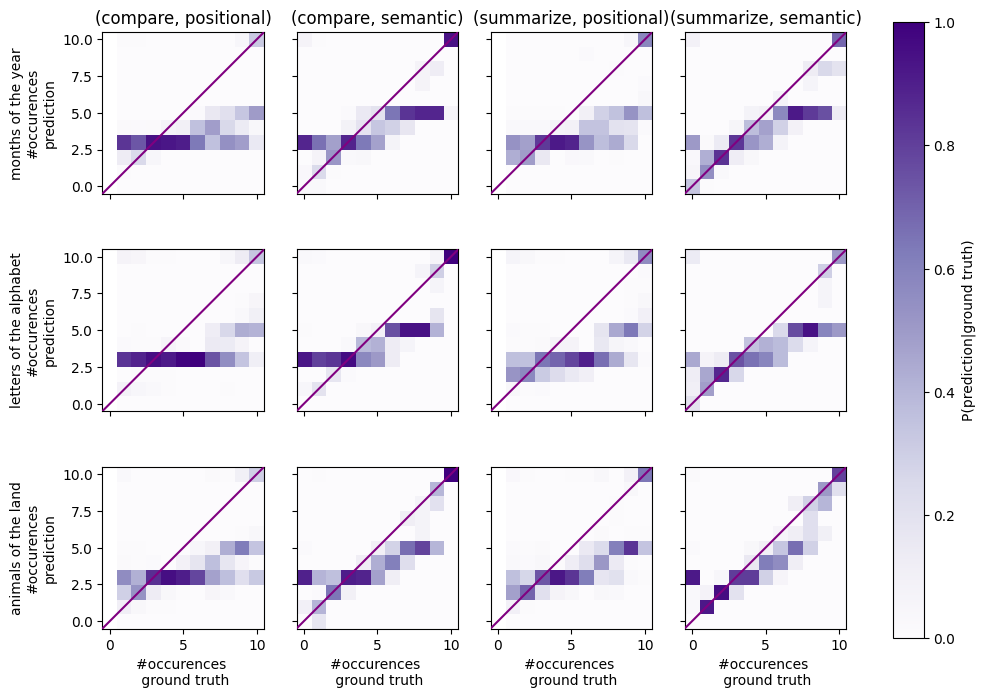

In [8]:
fig, axes = plt.subplots(len(experiments), 4, figsize=(12, 8),sharex=True,sharey=True)


for i, (category, items) in enumerate(experiments):
    name = category
    filename = f'{model_name}_{category.replace(" ","_")}_results.pkl'
    results = pickle.load(open(filename, 'rb'))
    
    X = { 'compare': {
        'Q_pos': np.zeros((11,11)),
        'Q_month': np.zeros((11,11))
        },
        'summarize': {
        'Q_pos': np.zeros((11,11)),
        'Q_month': np.zeros((11,11))
        }
    }
    
    axes_map = { 'compare': {
        'Q_pos': axes[i,0],
        'Q_month': axes[i,1],
        },
        'summarize': {
        'Q_pos': axes[i,2],
        'Q_month': axes[i,3]
        }
    }
    
    title_map = { 'compare': {
        'Q_pos': '(compare, positional)',
        'Q_month': '(compare, semantic)',
        },
        'summarize': {
        'Q_pos': '(summarize, positional)',
        'Q_month': '(summarize, semantic)'
        }
    }
    
    
    
    axes[i,0].set_ylabel(f'{name}\n#occurences\nprediction')
        
    skipped = 0
    preds = 0
    for gt, pred, Q_mode, Q_loc, sampling_style in results:
        if pred is not None and pred <= 10:
            X[Q_mode][Q_loc][pred, gt] += 1
        elif pred is not None and pred > 10:
            #print(pred, 'out of bounds')
            skipped += 1
            pass
        else:
            #print('NAN')
            skipped
            pass
        preds += 1
        
    print(f'For {name} skipped {skipped/preds:.3f} fraction of predictions due to out of bounds or None.')


    for Q_mode in ['compare','summarize']:
        for Q_loc in ['Q_pos','Q_month']:
            ax = axes_map[Q_mode][Q_loc]
            
            if i == 0:
                ax.set_title(title_map[Q_mode][Q_loc])
            
            R = X[Q_mode][Q_loc]
            R = R / R.sum(axis=0,keepdims=True)
            img = ax.imshow(R,cmap='Purples',vmin=0,vmax=1)
            ax.set_ylim(-0.5,10.5)
            ax.plot([-0.5,10.5],[-0.5,10.5],c='purple',zorder=100)

for i in range(4):
    axes[-1,i].set_xlabel('#occurences \n ground truth')
    
    
# use the mappable
plt.colorbar(img, ax=axes.ravel().tolist(),label='P(prediction|ground truth)')
plt.savefig('mistral.pdf',dpi=300,bbox_inches='tight')
    